<a href="https://colab.research.google.com/github/Aswin123358/IPL-Match-Winner-Prediction-Model/blob/main/IPL_prediction_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
import zipfile

zip_path = '/content/archive.zip'   # your file name
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
df = pd.read_csv('/content/data/ipl_matches_data.csv')
df.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,36.0,win
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,57.0,win
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,71.0,win


In [ ]:
df = df[['team1','team2','toss_winner','toss_decision','venue','match_winner']]
df = df.dropna()
df.head()

,team1,team2,toss_winner,toss_decision,venue,match_winner
0,1,6,1,field,M Chinnaswamy Stadium,6
1,2,1,1,field,"Rajiv Gandhi International Stadium, Uppal",2
2,4,3,4,field,Maharashtra Cricket Association Stadium,4
3,5,6,6,field,Saurashtra Cricket Association Stadium,6
4,494,4,494,field,Holkar Cricket Stadium,494


In [ ]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('match_winner', axis=1)
y = df['match_winner']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [ ]:
results = {}
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc}")
    print(classification_report(y_test, pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre


Logistic Regression Accuracy: 0.2264957264957265
              precision    recall  f1-score   support

           0       0.24      0.50      0.33        22
           1       0.00      0.00      0.00        27
           2       0.35      0.48      0.41        33
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.07      0.07      0.07        27
           6       0.28      0.19      0.22        27
           7       0.18      0.30      0.22        20
           8       0.27      0.29      0.28        21
           9       0.21      0.21      0.21        28
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00        10
          12       0.00      0.00      0.00         1
          13       0.33      0.25      0.29         4

    accuracy                           0.23       234
   macro avg       0.14      0.16      0.14       234
weighted avg       0.18      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

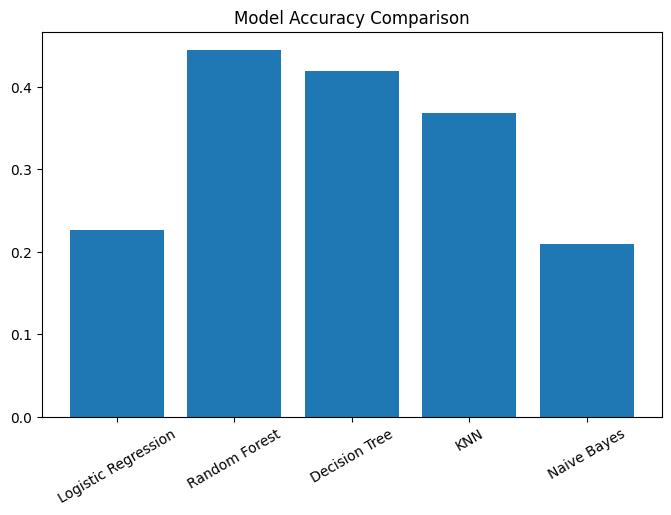

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

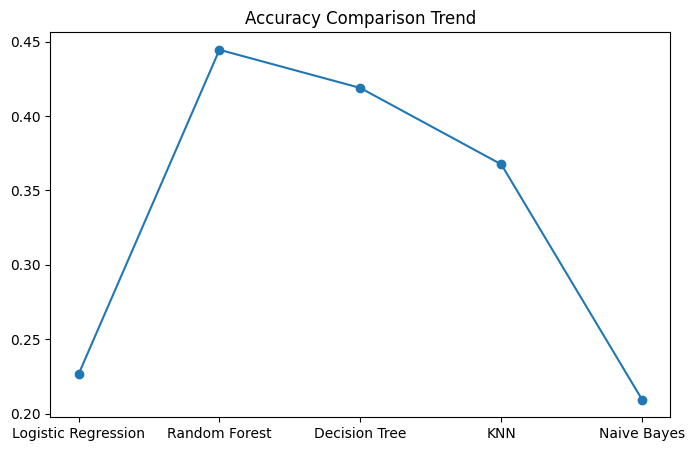

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Accuracy Comparison Trend")
plt.show()

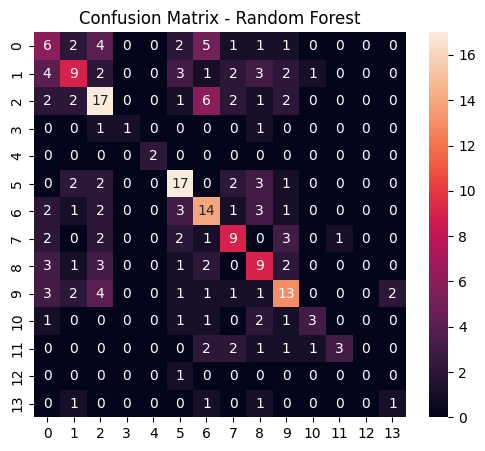

In [ ]:
best_model = max(results, key=results.get)
model = models[best_model]

pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model}")
plt.show()

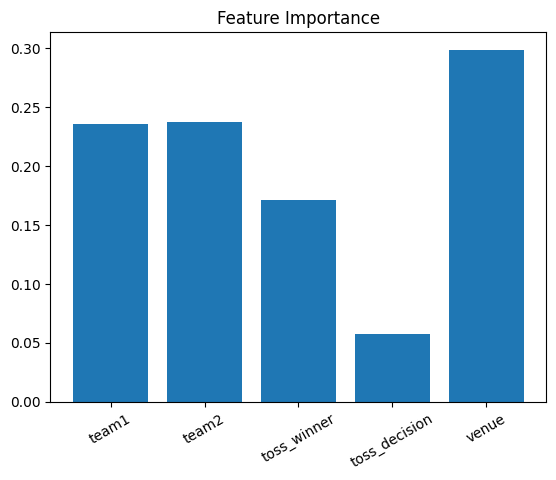

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=30)
plt.title("Feature Importance")
plt.show()

In [ ]:
def predict_match(team1, team2, toss_winner, toss_decision, venue):
    input_data = np.array([[team1, team2, toss_winner, toss_decision, venue]])
    prediction = model.predict(input_data)
    return prediction

# Example
predict_match(1, 2, 1, 0, 3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([2])

In [ ]:
import gradio as gr

def predict(team1, team2, toss_winner, toss_decision, venue):
    data = np.array([[team1, team2, toss_winner, toss_decision, venue]])
    return model.predict(data)

gr.Interface(
    fn=predict,
    inputs=["number","number","number","number","number"],
    outputs="text"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://18e90743fee4838e73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
